In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.lines as mlines
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
import scipy.io

## this script is to visualize the behaviour prob with predicted prob

pred_path = "C:/Users/wenlou/Documents/MATLAB/Prediction_est"
work_path = "C:/Users/wenlou/Documents/Python Scripts"
#data_path = "P:/3026008.01/Data/"
os.chdir(work_path)

In [4]:

data = dict()

locs = [-12, -4, 4, 12]
# input sub id and model id
m_lst = [70, 74]
sub_id = 25

for m_id in m_lst:
    mat_file_name = os.path.join(pred_path, 'm_' + str(m_id) + '_sub_' +str(sub_id) + '.mat' )
    data['m_'+str(m_id)] = scipy.io.loadmat(mat_file_name)
    
m_lbls = ['m_' + str(m_id) for m_id in m_lst] 
cond = data[m_lbls[0]]['cond']
condNLL = np.column_stack([data[m_lbls[0]]['condNLL'], data[m_lbls[1]]['condNLL']])





In [10]:
data

{'m_70': {'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Aug 24 11:38:07 2026',
  '__version__': '1.0',
  '__globals__': [],
  'NLL': array([[3743.04871124]]),
  'cond': array([[-12, -12, -12,   1],
         [ -4, -12, -12,   1],
         [  4, -12, -12,   1],
         [ 12, -12, -12,   1],
         [-12,  -4, -12,   1],
         [ -4,  -4, -12,   1],
         [  4,  -4, -12,   1],
         [ 12,  -4, -12,   1],
         [-12,   4, -12,   1],
         [ -4,   4, -12,   1],
         [  4,   4, -12,   1],
         [ 12,   4, -12,   1],
         [-12,  12, -12,   1],
         [ -4,  12, -12,   1],
         [  4,  12, -12,   1],
         [ 12,  12, -12,   1],
         [-12, -12,  -4,   1],
         [ -4, -12,  -4,   1],
         [  4, -12,  -4,   1],
         [ 12, -12,  -4,   1],
         [-12,  -4,  -4,   1],
         [ -4,  -4,  -4,   1],
         [  4,  -4,  -4,   1],
         [ 12,  -4,  -4,   1],
         [-12,   4,  -4,   1],
         [ -4,   4,  -4,   1],
 

In [5]:
np.column_stack([data[m_lbls[0]]['NLL'], data[m_lbls[1]]['NLL']])

array([[3743.04871124, 4094.34944612]])

In [6]:
df_NLL = pd.DataFrame(index = range(cond.shape[0]*2))
df_NLL.loc[range(cond.shape[0]), 'm_lbl'] = m_lbls[0]
df_NLL.loc[range(cond.shape[0], cond.shape[0]*2) ,'m_lbl'] = m_lbls[1]

df_NLL.loc[range(cond.shape[0]), 'NLL'] = data[m_lbls[0]]['condNLL']
df_NLL.loc[range(cond.shape[0], cond.shape[0]*2) ,'NLL'] = data[m_lbls[1]]['condNLL']
df_NLL[['sa','sv','s_uni','aud_f']] = np.vstack((cond, cond))

C:\Users\wenlou\AppData\Local\Temp\ipykernel_28992\484575844.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


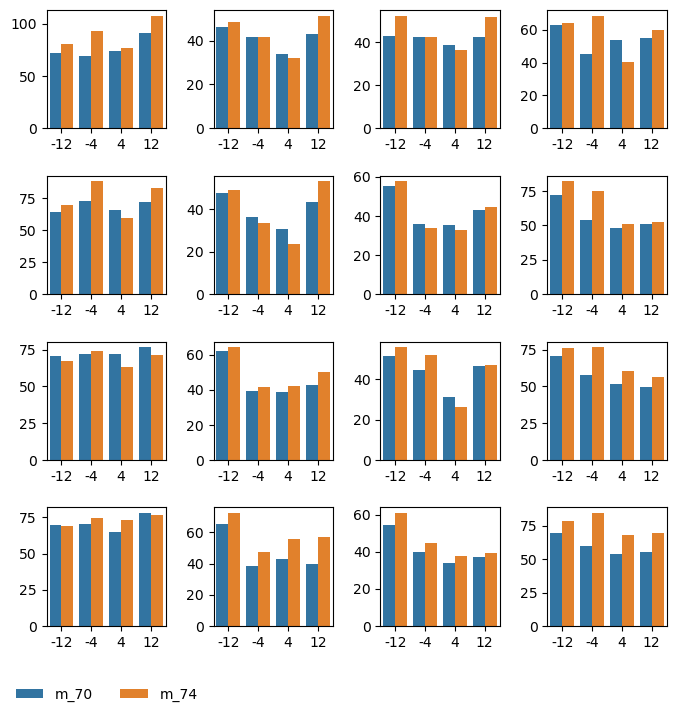

In [7]:
aud_f = 1 # aud - 1; vis - 0
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(8, 8), gridspec_kw={'hspace': 0.4, 'wspace': 0.4})
for i in np.arange(4):
    for j in np.arange(4):
        sns.barplot(df_NLL.loc[(df_NLL.sa==locs[i]) & (df_NLL.sv==locs[j]) & (df_NLL.aud_f==aud_f)], x="s_uni", y="NLL", hue="m_lbl", ax = axs[i,j])
        axs[i,j].set_xlabel('')
        axs[i,j].set_ylabel('')

for ax in axs.flat:
    ax.legend().remove()
    
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.2, 0), frameon=False)
# Show the plot
plt.tight_layout() 
plt.show()

In [8]:
df_NLL

,m_lbl,NLL,sa,sv,s_uni,aud_f
0,m_70,71.461500,-12,-12,-12,1
1,m_70,64.197840,-4,-12,-12,1
2,m_70,70.517247,4,-12,-12,1
3,m_70,69.767453,12,-12,-12,1
4,m_70,46.062395,-12,-4,-12,1
...,...,...,...,...,...,...
251,m_74,2.955955,12,4,12,0
252,m_74,7.392537,-12,12,12,0
253,m_74,4.445615,-4,12,12,0
254,m_74,5.111817,4,12,12,0


In [41]:
### look int odetails of the two conditions
cond_p = [12, 12, -4, 1]
cidx = (cond==cond_p).all(axis=1)

detailNLL0 = np.squeeze(data[m_lbls[0]]['detailNLL'][cidx])
detailNLL1 = np.squeeze(data[m_lbls[1]]['detailNLL'][cidx]) 
detailNLL0_sumloc = np.sum(detailNLL0, axis=2)
detailNLL1_sumloc = np.sum(detailNLL1, axis=2)

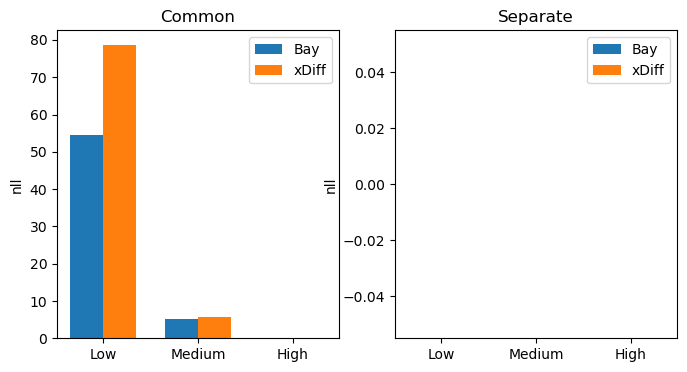

In [42]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), gridspec_kw={'hspace': 0.2, 'wspace': 0.2})
x = np.arange(3)
width = 0.35

axs[0].bar(x - width/2, detailNLL0_sumloc[0, :], width, label="Bay")
axs[0].bar(x + width/2, detailNLL1_sumloc[0, :], width, label="xDiff")

axs[0].set_xticks(x)
axs[0].set_xticklabels(["Low", "Medium", "High"])
axs[0].set_ylabel("nll")
axs[0].legend()
axs[0].set_title("Common")

axs[1].bar(x - width/2, detailNLL0_sumloc[1, :], width, label="Bay")
axs[1].bar(x + width/2, detailNLL1_sumloc[1, :], width, label="xDiff")

axs[1].set_xticks(x)
axs[1].set_xticklabels(["Low", "Medium", "High"])
axs[1].set_ylabel("nll")
axs[1].legend()
axs[1].set_title("Separate")
plt.show()

In [35]:
### look int odetails of the two conditions
cond_p = [-4, 12, -4, 1]
cidx = (cond==cond_p).all(axis=1)

detailBEH = np.squeeze(data[m_lbls[0]]['detailBEH'][cidx])
detailPRED0 = np.squeeze(data[m_lbls[0]]['detailPRED'][cidx])
detailPRED1 = np.squeeze(data[m_lbls[1]]['detailPRED'][cidx])

detailBEH_sumloc = np.sum(detailBEH, axis=2)
detailPRED0_sumloc = np.sum(detailPRED0, axis=2)
detailPRED1_sumloc = np.sum(detailPRED1, axis=2) 


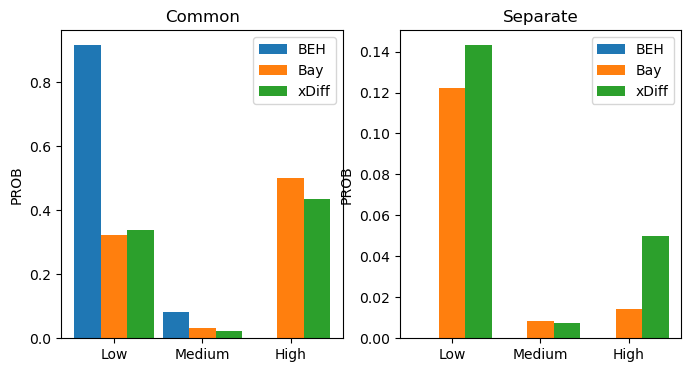

In [38]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 4), gridspec_kw={'hspace': 0.2, 'wspace': 0.2})
x = np.arange(3)
width = 0.3

axs[0].bar(x - width, detailBEH_sumloc[0, :], width, label="BEH")
axs[0].bar(x , detailPRED0_sumloc[0, :], width, label="Bay")
axs[0].bar(x + width, detailPRED1_sumloc[0, :], width, label="xDiff")

axs[0].set_xticks(x)
axs[0].set_xticklabels(["Low", "Medium", "High"])
axs[0].set_ylabel("PROB")
axs[0].legend()
axs[0].set_title("Common")

axs[1].bar(x - width, detailBEH_sumloc[1, :], width, label="BEH")
axs[1].bar(x , detailPRED0_sumloc[1, :], width, label="Bay")
axs[1].bar(x + width, detailPRED1_sumloc[1, :], width, label="xDiff")

axs[1].set_xticks(x)
axs[1].set_xticklabels(["Low", "Medium", "High"])
axs[1].set_ylabel("PROB")
axs[1].legend()
axs[1].set_title("Separate")
plt.show()

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 8), gridspec_kw={'hspace': 0.2, 'wspace': 0.2})
for i in np.arange(2):
    #mini dataframe
    df_dll = pd.DataFrame({'NLL': np.append(detailNLL0[i,j,:], detailNLL1[i,j,:]), 'M_id': np.repeat(m_lbls, 4), 
                            'r_s': np.append(locs, locs)})
    sns.barplot(df_dll, x = 'r_s', y = 'NLL', hue = 'M_id', ax = axs[i,j])
    axs[i,j].set_xlabel('')
    axs[i,j].set_ylabel('')
for ax in axs.flat:
    ax.legend().remove()
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.2, 0), frameon=False)
# Show the plot
plt.tight_layout() 
plt.show()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_7976\600505945.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


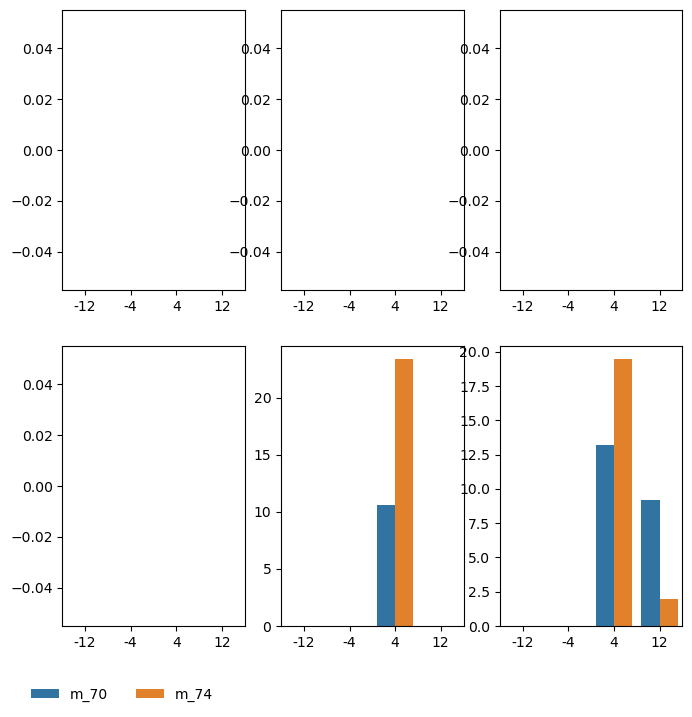

In [ ]:


fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 8), gridspec_kw={'hspace': 0.2, 'wspace': 0.2})
for i in np.arange(2):
    for j in np.arange(3):
        #mini dataframe
        df_dll = pd.DataFrame({'NLL': np.append(detailNLL0[i,j,:], detailNLL1[i,j,:]), 'M_id': np.repeat(m_lbls, 4), 
                               'r_s': np.append(locs, locs)})
        sns.barplot(df_dll, x = 'r_s', y = 'NLL', hue = 'M_id', ax = axs[i,j])
        axs[i,j].set_xlabel('')
        axs[i,j].set_ylabel('')
for ax in axs.flat:
    ax.legend().remove()
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.2, 0), frameon=False)
# Show the plot
plt.tight_layout() 
plt.show()

C:\Users\wenlou\AppData\Local\Temp\ipykernel_28992\801751915.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


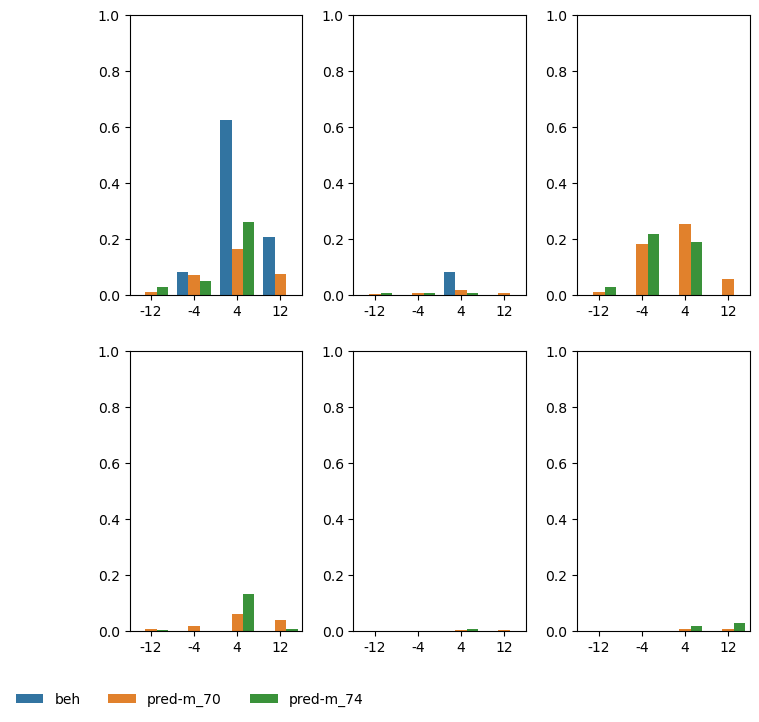

In [32]:

# beh against pred
detailBEH = np.squeeze(data[m_lbls[0]]['detailBEH'][cidx])
detailPRED0 = np.squeeze(data[m_lbls[0]]['detailPRED'][cidx])
detailPRED1 = np.squeeze(data[m_lbls[1]]['detailPRED'][cidx])

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(8, 8), gridspec_kw={'hspace': 0.2, 'wspace': 0.3})
for i in np.arange(2):
    for j in np.arange(3):
        #mini dataframe
        df_dll = pd.DataFrame({'prob': np.concatenate((detailBEH[i,j,:], detailPRED0[i,j,:], detailPRED1[i,j,:])), 
                               'type': np.repeat(['beh', 'pred-' + m_lbls[0], 'pred-' + m_lbls[1]], 4), 
                               'r_s': np.concatenate((locs, locs,locs))})
        sns.barplot(df_dll, x = 'r_s', y = 'prob', hue = 'type', ax = axs[i,j])
        axs[i,j].set_xlabel('')
        axs[i,j].set_ylabel('')
        axs[i,j].set_ylim(0, 1)
for ax in axs.flat:
    ax.legend().remove()
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.2, 0), frameon=False)
# Show the plot
plt.tight_layout() 
plt.show()